# The POLONAISE UHDM data release

**Paper element.** Supplemental Material, Analysis Code and Data Release: this is
a guided tour of the file that section describes.

**Private.** A guided tour of the POLONAISE UHDM data release: a single,
self-describing HDF5 file holding the **whole limit-setting calculation** —
not just the final contour — as a dense array over
(`f_DM`, atmosphere, sensor mode, `alpha_n`, `m_DM`, mediator range `lambda`).
Notebooks 01–05 read this file through `luhdm.release` rather than
recomputing any physics, so a notebook run and a cluster run cannot drift.

**What's inside**, group by group (the full schema table lives in
[`release/README.md`](../release/README.md), which this notebook mirrors and
does not contradict):

- `/axes` — every coordinate array, including the two **hypothesis** axes
  `f_dm` and `atmosphere` (section 3 below).
- `/results` — the cube itself: `extremeness` (the optimum-interval
  confidence), `mu` (expected counts), `status` (how the cell was obtained),
  and the mode-less `n_transit`.
- `/detector` — the observed candidate lists, the pre-selection blips, and
  the measured detection efficiency $\varepsilon(q)$ per mode.
- `/halo` — an independent, coarser flux/reach diagnostic grid, for
  intuition and figures.
- `/reference_curves` — showcase arrival-speed and raw-spectrum curves (the
  data behind notebook 02).

**Two ways in**, covered in that order below: **(1)** raw `h5py` plus the
standalone, dependency-light
[`release/luhdm_release.py`](../release/luhdm_release.py) reader — no
`luhdm` install required — and **(2)** the `luhdm.release` convenience loader,
for anyone who already has this repository checked out.

This tutorial re-executes against whichever cube the release loader points at,
which is `luhdm.release.DEFAULT_PATH` (currently the v5 build). Everything below
is schema-driven — it reads tag names, axis lengths and the massless sentinel
from the file's own attributes, never from a hardcoded list — so it keeps
working unchanged when a newer cube supersedes this one.

**A path note.** The raw-`h5py` walkthrough of section 1 deliberately does not
import `luhdm`, so it needs a filename; it takes that filename from
`luhdm.release.DEFAULT_PATH` in the cell below purely so the two halves of the
notebook can never read different files.

## 1. You do not need to install anything

The release is plain HDF5 with dimension scales and per-dataset `units` /
`description` attributes. `h5py`, `h5ls`, `h5dump`, MATLAB, Julia, IDL and
xarray (via h5netcdf) all open it — nothing to `pip install` beyond whatever
HDF5 binding you already have.

In [1]:
%matplotlib inline
import json
import sys
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt

from luhdm import release as _release

REPO = Path.cwd().parent            # notebooks/ -> repo root
RELEASE_DIR = REPO / "release"
# The one source of truth for which cube this repository ships. Section 1 below
# opens it with bare h5py to show that no luhdm code is needed to read it; we
# only borrow the *path* here so both halves of the notebook read one file.
H5_PATH = _release.DEFAULT_PATH
assert H5_PATH.exists(), f"no cube at {H5_PATH} -- point this at whatever release/ holds"
print(f"cube: {H5_PATH.name}  ({H5_PATH.stat().st_size / 1e6:.1f} MB)")

cube: luhdm_datarelease_v5.h5  (14.8 MB)


In [2]:
# The whole tree, straight from h5py -- no luhdm code, just the HDF5 library.
def show(name, obj):
    if isinstance(obj, h5py.Dataset):
        units = obj.attrs.get("units", "")
        print(f"{name:32s} {str(obj.shape):20s} {str(obj.dtype):8s} [{units}]")

with h5py.File(H5_PATH, "r") as f:
    print(f.attrs["version_tag"], f["results/extremeness"].shape)
    f.visititems(show)

v5.0-night-m0p356mg-bcap10cm (2, 2, 3, 44, 119, 55)
axes/alpha_halo_n                (64,)                float64  [1]
axes/alpha_n                     (44,)                float64  [1]
axes/atmosphere                  (2,)                 int8     [bool]
axes/f_dm                        (2,)                 float64  [1]
axes/lambda_m                    (55,)                float64  [m]
axes/m_phi_gev                   (55,)                float64  [GeV]
axes/mass_gev                    (119,)               float64  [GeV]
axes/mass_halo_gev               (64,)                float64  [GeV]
axes/mode                        (3,)                 uint8    [1]
detector/all_blips_mode1         (66,)                float64  [eV]
detector/all_blips_mode2         (99,)                float64  [eV]
detector/all_blips_mode3         (443,)               float64  [eV]
detector/eff_1_df2               (400,)               float64  [1]
detector/eff_1_df3               (400,)               float64  [1

`/results/extremeness` is shaped `(f_dm, atmosphere, mode, alpha_n, mass_gev,
lambda_m)`. A first slice, hard-coding the leading indices to see the shape of
things — **do not do this in real code**, resolve indices from the axes
instead (as every section below does):

In [3]:
with h5py.File(H5_PATH, "r") as f:
    p = f["results/extremeness"][0, 0, 0, :, :, -1]   # f_DM idx0, atm idx0, mode idx0, massless
    print("axis lengths:", {d: len(f["axes"][d]) for d in f["axes"]})
    print("excluded cells at 95% CL:", int((p >= 0.95).sum()), "of", p.size)

    # named mediator-range tags and the massless convention -- read from the
    # file's own attributes, never assumed
    tags = json.loads(f["axes/lambda_m"].attrs["tags_json"])
    n_finite = int(f["axes/lambda_m"].attrs["n_finite"])
print("named lambda tags (m):", tags)
print(f"lambda_m axis: {n_finite} finite values (ascending) + 1 massless "
      f"sentinel (inf, where m_phi_gev == 0.0)")

axis lengths: {'alpha_halo_n': 64, 'alpha_n': 44, 'atmosphere': 2, 'f_dm': 2, 'lambda_m': 55, 'm_phi_gev': 55, 'mass_gev': 119, 'mass_halo_gev': 64, 'mode': 3}
excluded cells at 95% CL: 1517 of 5236
named lambda tags (m): {'2m': 2.0, '20cm': 0.2, '2cm': 0.02, '2mm': 0.002, '200um': 0.0002, '20um': 2e-05, '10um': 1e-05, '2um': 2e-06}
lambda_m axis: 54 finite values (ascending) + 1 massless sentinel (inf, where m_phi_gev == 0.0)


### The standalone reader (no `luhdm` install needed)

[`release/luhdm_release.py`](../release/luhdm_release.py) is a **single
self-contained file** — copy it next to the `.h5` and `import` it. It needs
only `numpy` and `h5py` (`pandas` is imported lazily inside `to_dataframe()`
and is optional), never imports the `luhdm` analysis package, and is entirely
**schema-driven**: axis names, tags and the massless sentinel come from the
file, so it keeps working across cube versions. What it adds over raw
`h5py`: selection by physical value (`mode=2`, `lam='200um'`, `f_dm=0.1`,
`atmosphere=True`, ...) with helpful errors, slices that carry their axes
with them, the exclusion-band convention (section 4), and a one-call
`summary()`.

In [4]:
sys.path.insert(0, str(RELEASE_DIR))
import luhdm_release

srel = luhdm_release.open_release(H5_PATH)
print(srel)
srel.summary()

<Release '~/code/luhdm/release/luhdm_datarelease_v5.h5' (v5.0-night-m0p356mg-bcap10cm)>
POLONAISE UHDM data release   v5.0-night-m0p356mg-bcap10cm
file            : ~/code/luhdm/release/luhdm_datarelease_v5.h5
format          : luhdm-datarelease version 2 (schema 1)
created         : 2026-08-08T12:10:42.831616+00:00
exposure        : 790,778 s  (219.66 h)
impact-param cap: 0.1 m
recommended CL  : 0.95

hypothesis axes
  f_dm          : [0.1, 1.0]  (default 0.1) -- DM fraction, pure flux scale
  atmosphere    : [1, 0] -> [True, False]  (1/True = attenuation applied)
  mode          : [1, 2, 3]

axes
  alpha_halo_n    n=64    2e-11 .. 1                   [1]
                  coupling alpha_n (halo/flux-map 64 grid)
  alpha_n         n=44    1e-10 .. 1                   [1]
                  per-neutron coupling alpha_n
  atmosphere      n=2     [1, 0]                       [bool]
                  1 = attenuation through the atmosphere/earth applied (atm pass); 0 = bare halo flux (noatm

The quickstart from the reader's own docstring: a slice, an excluded band, and
a single-cell dump, entirely without installing `luhdm`.

In [5]:
sl = srel.get("extremeness", mode=1, lam="200um", f_dm=0.1, atmosphere=True)
print(sl)                                        # axes travel with the array
print("excluded cells:", int((sl.values >= 0.95).sum()))

band = srel.excluded_band(mode=1, lam="200um")   # 95% CL, per mass
print(band)

cell = srel.cell(mode=2, alpha=1e-3, mass=1e8, lam="200um")
print({k: cell[k] for k in
       ("mass_gev", "alpha_n", "mu", "extremeness", "status", "status_meaning")})

<Slice extremeness [1] (alpha_n=44, mass_gev=119) at f_dm=0.1, atmosphere=True, mode=1, lambda_m=0.0002>
excluded cells: 587
<ExcludedBand 95% CL at f_dm=0.1, atmosphere=True, mode=1, lambda_m=0.0002: 33/119 masses excluded, mass range 5.203e+05..3.438e+09 GeV>
{'mass_gev': 96471330.72266711, 'alpha_n': 0.0009478599776522384, 'mu': 148.25978088378906, 'extremeness': 1.0, 'status': 3, 'status_meaning': 'mu>mu_cap: expected counts above the MC cap; extremeness is exactly 1 (excluded)'}


## 2. For people with this repository: `luhdm.release`

If you already have this repo checked out, `luhdm.release` is a thinner,
faster-to-type convenience layer over the same file: eager axis loading,
exact/nearest index resolution, hyperslab plane reads (`mass_plane`,
`lambda_plane`, `composite`), and the shared best-mass criterion that keeps
notebooks 01 and 04 from drifting apart. `open_release()` with no argument
opens `luhdm.release.DEFAULT_PATH`, the cube tracked in `release/`, which is the
same file section 1 opened by name.

In [6]:
from luhdm import release

rel = release.open_release(H5_PATH)   # DEFAULT_PATH is currently stale; see above
print(rel)
print(rel.tree())

<Release ~/code/luhdm/release/luhdm_datarelease_v5.h5 (v5.0-night-m0p356mg-bcap10cm)>
/
  axes/
    alpha_halo_n  (64,) float64  [1]
    alpha_n  (44,) float64  [1]
    atmosphere  (2,) int8  [bool]
    f_dm  (2,) float64  [1]
    lambda_m  (55,) float64  [m]
    m_phi_gev  (55,) float64  [GeV]
    mass_gev  (119,) float64  [GeV]
    mass_halo_gev  (64,) float64  [GeV]
    mode  (3,) uint8  [1]
  detector/
    all_blips_mode1  (66,) float64  [eV]
    all_blips_mode2  (99,) float64  [eV]
    all_blips_mode3  (443,) float64  [eV]
    eff_1_df2  (400,) float64  [1]
    eff_1_df3  (400,) float64  [1]
    eff_2_df2  (400,) float64  [1]
    eff_2_df3  (400,) float64  [1]
    eff_3_df2  (400,) float64  [1]
    eff_3_df3  (400,) float64  [1]
    events_mode1  (8,) float64  [GeV]
    events_mode2  (26,) float64  [GeV]
    events_mode3  (126,) float64  [GeV]
    exposure_s  () float64  [s]
    q_gev_1  (400,) float64  [GeV]
    q_gev_2  (400,) float64  [GeV]
    q_gev_3  (400,) float64  [GeV]
  

In [7]:
# same one-cell dump as the standalone reader, through the loader
info = rel.cell(mass=1e8, alpha=1e-3, lam="200um", mode=2)
print("resolved cell (nearest-in-log10 for mass/alpha, exact for lambda):")
for k, v in info.items():
    print(f"  {k:16s} {v}")

resolved cell (nearest-in-log10 for mass/alpha, exact for lambda):
  mass_gev         96471330.72266711
  alpha_n          0.0009478599776522384
  lambda_m         0.0002
  f_dm             0.1
  atmosphere       True
  indices          (30, 25, 29)
  extremeness      1.0
  mu               148.25978088378906
  n_transit        702.0191040039062
  status           3
  bmax             0.0027313425671309233
  n_transit_halo   1690.232177734375


## 3. The 2 × 2 hypothesis structure: `f_dm` × `atmosphere`

The two leading axes of every `/results` dataset are **hypotheses**, not
measurements — every combination is fully computed, so the cube holds four
parallel analyses:

|  | `atmosphere = 1` (attenuated) | `atmosphere = 0` (bare halo) |
|---|---|---|
| **`f_dm = 0.1`** | this species is a tenth of the dark matter; the plane the composite cross-section benchmark is quoted on | what that limit would be with no overburden |
| **`f_dm = 1.0`** | this species is all of the dark matter; the plane the Letter's $\alpha_n$ limits are quoted on | ditto, no overburden |

* **`f_dm`** is the fraction of the local dark-matter density carried by this
  species. It enters only as a flux normalisation, so `mu` and `n_transit`
  scale exactly linearly with it — `extremeness` does **not**, since it is a
  non-linear function of `mu`. `attrs['f_dm_default']` records the value the
  loader falls back to when a caller does not ask for one; it is not a statement
  about which plane a given published number is quoted on, and both planes are
  used in the paper.
* **`atmosphere`** selects whether the arrival flux has been propagated
  through the atmosphere/overburden. With it on, strongly coupled candidates
  are slowed or stopped before reaching the sensor and the exclusion closes
  from above; with it off there is no such ceiling (see the caveat in
  section 4).

`axes/atmosphere` is stored `[1, 0]`, so **`atmosphere = 0` is index 1, not
index 0** — the single easiest thing to get wrong in this file. Select by
value, never by position:

In [8]:
with h5py.File(H5_PATH, "r") as f:
    f_dm_axis = f["axes/f_dm"][:]
    atm_axis = f["axes/atmosphere"][:]
    mode_axis = f["axes/mode"][:]
    i_f = int(np.flatnonzero(f_dm_axis == 0.1)[0])
    i_atm_on = int(np.flatnonzero(atm_axis == 1)[0])
    i_mod = int(np.flatnonzero(mode_axis == 2)[0])

print("axes/f_dm       =", f_dm_axis, " -> f_dm=0.1 is index", i_f)
print("axes/atmosphere =", atm_axis, " -> atmosphere ON is index", i_atm_on)
print("axes/mode       =", mode_axis, " -> mode 2 is index", i_mod)

axes/f_dm       = [0.1 1. ]  -> f_dm=0.1 is index 0
axes/atmosphere = [1 0]  -> atmosphere ON is index 0
axes/mode       = [1 2 3]  -> mode 2 is index 1


The loader does exactly this resolution for you via the `f_dm=` /
`atmosphere=` keywords on every accessor. All four hypotheses, one mode and
mediator range at a time:

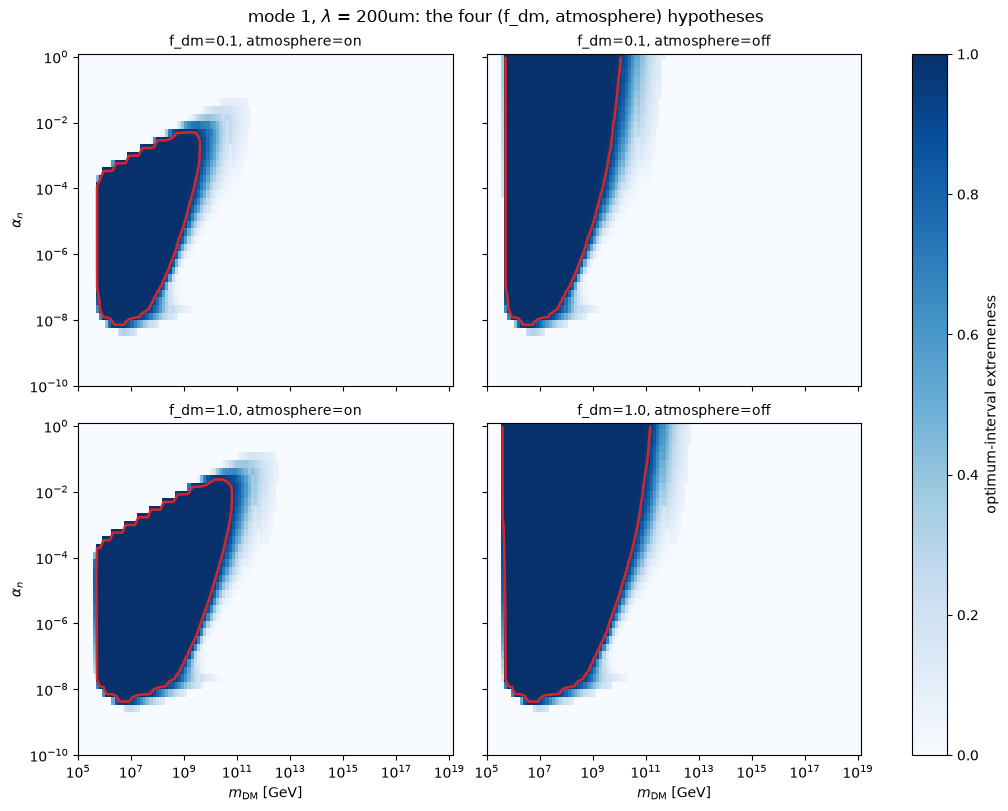

In [9]:
FIG_MODE, FIG_LAM = 1, "200um"
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True,
                         constrained_layout=True)
mesh = None
for row, f_dm in enumerate((0.1, 1.0)):
    for col, atm in enumerate((True, False)):
        a = axes[row, col]
        P = rel.mass_plane("extremeness", mode=FIG_MODE, lam=FIG_LAM,
                           f_dm=f_dm, atmosphere=atm)
        mesh = a.pcolormesh(rel.axes.mass_gev, rel.axes.alpha_n, P, cmap="Blues",
                            vmin=0, vmax=1, shading="auto")
        a.contour(rel.axes.mass_gev, rel.axes.alpha_n, P, levels=[0.95],
                 colors="#d62728", linewidths=1.8)
        a.set_xscale("log")
        a.set_yscale("log")
        a.set_title(f"f_dm={f_dm}, atmosphere={'on' if atm else 'off'}", fontsize=10)
for a in axes[-1, :]:
    a.set_xlabel(r"$m_{\rm DM}$ [GeV]")
for a in axes[:, 0]:
    a.set_ylabel(r"$\alpha_n$")
fig.colorbar(mesh, ax=axes, label="optimum-interval extremeness")
fig.suptitle(f"mode {FIG_MODE}, $\\lambda$ = {FIG_LAM}: "
             "the four (f_dm, atmosphere) hypotheses", fontsize=12)
plt.show()

## 4. The exclusion-band convention

`extremeness` is the probability that a background-free pseudo-experiment
under a hypothesis looks *less* extreme than the observed data (Yellin's
optimum-interval method). A grid point is **excluded at confidence `C`**
when `extremeness >= C` — a 2-D exclusion region is just that level set,
contoured directly.

For a boundary *in the coupling*, the project quotes the interpolated
crossing rather than the last excluded grid point: at each mass, the run of
`alpha_n` indices with `extremeness >= C` is bracketed and the level crossing
is found by linear interpolation in `log10(alpha_n)`. If the excluded run
already starts at the first (or ends at the last) scanned coupling there is
nothing to bracket, and that edge **saturates** at the end of the grid — a
property of the scan range, not a measurement.

Three independent routes to the same number: the loader, the standalone
reader, and the raw arithmetic each of them wraps.

In [10]:
MASS, LAM, MODE = 1e8, "200um", 1

# 1) luhdm.release
lo, hi = rel.excluded_alpha_band(mass=MASS, lam=LAM, mode=MODE)
print(f"loader             95% CL: alpha_n in [{lo:.4e}, {hi:.4e}]")

# 2) the standalone reader -- no luhdm import at all
band = srel.excluded_band(mode=MODE, lam=LAM)
im = int(np.argmin(np.abs(np.log10(band.mass_gev) - np.log10(MASS))))
print(f"standalone reader  95% CL: alpha_n in "
      f"[{band.alpha_lo[im]:.4e}, {band.alpha_hi[im]:.4e}]  "
      f"(nearest grid mass {band.mass_gev[im]:.4g} GeV)")

# 3) by hand, straight off the HDF5 column -- what both of the above wrap
with h5py.File(H5_PATH, "r") as f:
    alpha = f["axes/alpha_n"][:]
    mass_ax = f["axes/mass_gev"][:]
    lam_ax = f["axes/lambda_m"][:]
    ifd = int(np.flatnonzero(f["axes/f_dm"][:] == 0.1)[0])
    iat = int(np.flatnonzero(f["axes/atmosphere"][:] == 1)[0])
    imode = int(np.flatnonzero(f["axes/mode"][:] == MODE)[0])
    im2 = int(np.argmin(np.abs(np.log10(mass_ax) - np.log10(MASS))))
    il = int(np.flatnonzero(lam_ax == 2e-4)[0])
    column = f["results/extremeness"][ifd, iat, imode, :, im2, il]

def band_by_hand(alpha, p, level):
    idx = np.where(p >= level)[0]
    if idx.size == 0:
        return np.nan, np.nan
    lo = (np.log10(alpha[0]) if idx[0] == 0 else np.interp(
        level, p[idx[0] - 1:idx[0] + 1], np.log10(alpha[idx[0] - 1:idx[0] + 1])))
    hi = (np.log10(alpha[-1]) if idx[-1] == len(p) - 1 else np.interp(
        -level, -p[idx[-1]:idx[-1] + 2], np.log10(alpha[idx[-1]:idx[-1] + 2])))
    return 10 ** lo, 10 ** hi

lo_h, hi_h = band_by_hand(alpha, column, 0.95)
print(f"by hand (numpy)    95% CL: alpha_n in [{lo_h:.4e}, {hi_h:.4e}]  "
      f"(mass snapped to {mass_ax[im2]:.4g} GeV)")

loader             95% CL: alpha_n in [6.8861e-08, 2.7952e-03]
standalone reader  95% CL: alpha_n in [6.8861e-08, 2.7952e-03]  (nearest grid mass 9.647e+07 GeV)
by hand (numpy)    95% CL: alpha_n in [6.8861e-08, 2.7952e-03]  (mass snapped to 9.647e+07 GeV)


**Caveat: atmosphere-off upper edges are grid artefacts, not ceilings.** With
attenuation on, strong couplings are stopped by the overburden and the
exclusion closes from above — a genuine two-sided band. With it off there is
no such mechanism, so the band simply continues past the top of the scanned
`alpha_n` grid and the upper edge is wherever the scan stopped. Computed live
against whichever cube this notebook has open (so the fractions below move
with the cube, not with this text):

In [11]:
with h5py.File(H5_PATH, "r") as f:
    ext = f["results/extremeness"][:]        # (f_dm, atm, mode, alpha, mass, lam)
    atm_axis = f["axes/atmosphere"][:]

above = ext >= 0.95
for i, on in enumerate(atm_axis):
    a = above[:, i]                          # (f_dm, mode, alpha, mass, lam)
    any_exc = a.any(axis=2)                  # any alpha excluded at this (mass, lam)
    top_exc = a[:, :, -1]                    # alpha_n = 1 (top of grid) excluded
    n = int(any_exc.sum())
    frac = 100 * (any_exc & top_exc).sum() / n if n else float("nan")
    print(f"atmosphere={int(on)} ({'on' if on else 'off'}): {n} excluded "
          f"(f_dm, mode, mass, lambda) columns, {frac:.1f}% saturate at alpha_n = 1")

atmosphere=1 (on): 11611 excluded (f_dm, mode, mass, lambda) columns, 1.3% saturate at alpha_n = 1
atmosphere=0 (off): 12118 excluded (f_dm, mode, mass, lambda) columns, 94.7% saturate at alpha_n = 1


## 5. Status codes and the NaN policy

`/results/status` records how each cell was obtained:

| code | meaning | `extremeness` |
|---|---|---|
| `0` | the optimum-interval Monte Carlo ran | MC value in (0, 1) |
| `1` | **the cell raised an exception** | `NaN` (and `mu`, `n_transit` too) |
| `2` | `mu` below the MC floor — nothing to expect | exactly `0.0` |
| `3` | `mu` above the MC cap — overwhelmingly excluded | exactly `1.0` |
| `4` | the spectrum has no support, `mu == 0` | exactly `0.0` |

Codes 2, 3 and 4 are exact deterministic shortcuts, not failures — they are
how the scan avoids Monte Carlo where the answer is already known, and they
are the majority of the cube. **Code 1 is a failure and needs care**: `NaN >=
0.95` is `False`, so a failed cell silently reads as "not excluded" in any
naive level-set. That is the published convention and this release does not
change it, but it is worth knowing where those cells sit. Computed live, and
cross-checked against the NaN pattern:

In [12]:
with h5py.File(H5_PATH, "r") as f:
    st = f["results/status"][:]
    ext = f["results/extremeness"][:]

legend = srel.status_legend()
codes, counts = np.unique(st, return_counts=True)
print(f"{'code':>4}  {'count':>12}  {'%':>6}  meaning")
for c, n in zip(codes.tolist(), counts.tolist()):
    print(f"{c:>4}  {n:>12,}  {100 * n / st.size:5.2f}%  {legend.get(c, '?')}")

print()
print("NaN extremeness exactly where status==1:",
      np.array_equal(np.isnan(ext), st == 1))
print(f"status-1 cells: {int((st == 1).sum()):,} "
      f"({100 * (st == 1).mean():.2f}% of the cube)")

code         count       %  meaning
   0       435,797  12.61%  ok(MC): the optimum-interval Monte Carlo ran
   1        52,548   1.52%  exception: the cell raised; extremeness/mu/n_transit are NaN, and NaN reads as NOT excluded
   2     2,226,349  64.42%  mu<0.2: expected counts below the MC floor; extremeness is exactly 0
   3       432,844  12.53%  mu>mu_cap: expected counts above the MC cap; extremeness is exactly 1 (excluded)
   4       308,222   8.92%  mu==0: the spectrum has no support; extremeness is exactly 0

NaN extremeness exactly where status==1: True
status-1 cells: 52,548 (1.52% of the cube)


The standalone reader's `excluded_band()` counts these for you
(`band.n_undefined` per mass) and warns unless you pass
`nan_policy='ignore'` — it never silently drops them.

## 6. Detector inputs, and verifying what you downloaded

A compressed look at `/detector` — the efficiency curves and the
reconstructed-blip / analysis-event distinction — plus how to check your copy
of the cube against the one this was built from.

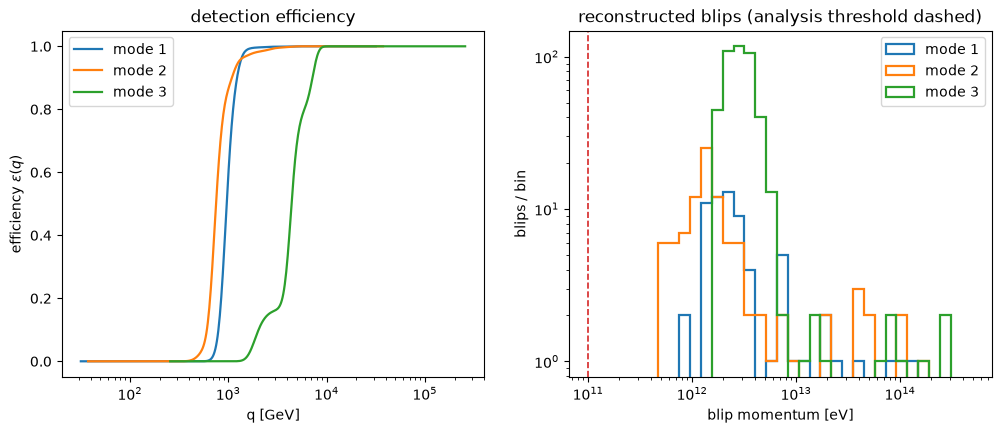

mode 1:    8 analysis events,   66 blips total
mode 2:   26 analysis events,   99 blips total
mode 3:  126 analysis events,  443 blips total


In [13]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 4.5))

for mode in (1, 2, 3):
    q, eff = rel.efficiency_curve(mode)
    a0.plot(q, eff, lw=1.6, label=f"mode {mode}")
a0.set_xscale("log")
a0.set_xlabel("q [GeV]")
a0.set_ylabel(r"efficiency $\varepsilon(q)$")
a0.set_title("detection efficiency")
a0.legend()

Q_TH_EV = rel.attrs["q_thresh_gev"] * 1e9   # GeV -> eV
allb = np.concatenate([rel.all_blips(m) for m in (1, 2, 3)])
bins = np.logspace(np.log10(allb.min()), np.log10(allb.max()), 30)
for mode in (1, 2, 3):
    a1.hist(rel.all_blips(mode), bins=bins, histtype="step", lw=1.6,
           label=f"mode {mode}")
a1.axvline(Q_TH_EV, color="#d62728", ls="--", lw=1.2)
a1.set_xscale("log")
a1.set_yscale("log")
a1.set_xlabel("blip momentum [eV]")
a1.set_ylabel("blips / bin")
a1.set_title("reconstructed blips (analysis threshold dashed)")
a1.legend()
plt.show()

for mode in (1, 2, 3):
    print(f"mode {mode}: {rel.events(mode).size:4d} analysis events, "
          f"{rel.all_blips(mode).size:4d} blips total")

**Build pipeline.** `scripts/build_release.py` runs one per-`lambda` shard at
a time on a many-core node (all randomness pinned to a single `seed`), and
`scripts/assemble_release.py` merges the shards into this file, computes the
reference curves, and writes `release/provenance.json` and
`release/SHA256SUMS`.

**Verify the download.** From the repository root: `sha256sum -c
release/SHA256SUMS`. Every root attribute below is read straight from the
file that is actually open, not typed in here, so it always matches whatever
cube this notebook ran against.

In [14]:
for k in ("version_tag", "created", "git_commit", "git_dirty", "seed",
         "t_exposure_s", "b_constrained_max_m", "df"):
    print(f"{k:22s} {rel.attrs.get(k)}")
print("packages", rel.attrs.get("packages_json"))

version_tag            v5.0-night-m0p356mg-bcap10cm
created                2026-08-08T12:10:42.831616+00:00
git_commit             1ca2828dddaa859c5ceee3be74fc81b388748ce1
git_dirty              False
seed                   20260702
t_exposure_s           790778.0
b_constrained_max_m    0.1
df                     3
packages {"numpy": "2.5.1", "scipy": "1.18.0", "h5py": "3.16.0", "optimum_interval": "0.3.0", "luhdm": "0.1.0", "matplotlib": "3.11.1", "pandas": "3.0.3", "python": "3.14.6"}


**Citation.** *POLONAISE UHDM data release* — DOI `<Zenodo placeholder>`. Cite
the release DOI alongside the analysis paper `<paper placeholder>`.

**What the numbers mean.** `extremeness >= C` at a point is the statement
that this `(f_DM, atmosphere, m_DM, alpha_n, lambda)` combination is
**excluded at confidence `C`** by the observed candidates, with no background
model assumed. Unmodelled backgrounds can only *weaken* an exclusion — never
fake one — so the excluded regions are conservative.

In [15]:
rel.close()
srel.close()
# A plain open + close is fine in a notebook. Scripts should prefer the
# context manager (either loader supports `with ... as rel:`), which closes
# the file even if an exception is raised mid-analysis.
print("release files closed")

release files closed
